# One-Sample & Two-Sample t-Tests

Topic 04 of the Statistical Inference & Hypothesis Testing repo. Topic 03 built a confidence interval for the difference of two means and noted informally that "if it excludes 0, that's evidence of a real difference." This notebook formalizes that into a proper hypothesis test — built from scratch, validated against `scipy.stats`, and checked the way Topic 03 checked CI coverage: by directly simulating the test's actual false-positive rate and actual power, rather than assuming the theory holds.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

np.random.seed(42)
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)
print("Setup complete.")

Setup complete.


## 1. The One-Sample t-Test, Built From Scratch

Tests $H_0: \mu = \mu_0$ against $H_1: \mu \ne \mu_0$ using

$$t = \frac{\bar{X} - \mu_0}{s/\sqrt{n}}, \qquad df = n - 1$$

then compares $t$ to the t-distribution to get a p-value.

In [2]:
def one_sample_ttest_scratch(sample, mu0):
    n = len(sample)
    sample_mean = sample.mean()
    sample_std = sample.std(ddof=1)
    t_stat = (sample_mean - mu0) / (sample_std / np.sqrt(n))
    df = n - 1
    p_value = 2 * (1 - stats.t.cdf(abs(t_stat), df=df))  # two-tailed
    return t_stat, df, p_value

print("One-sample t-test function defined.")

One-sample t-test function defined.


In [3]:
hypothesized_mu = 100
true_mu, true_sigma = 104, 15
sample1 = np.random.normal(true_mu, true_sigma, size=30)

t_manual, df_manual, p_manual = one_sample_ttest_scratch(sample1, hypothesized_mu)
t_scipy, p_scipy = stats.ttest_1samp(sample1, hypothesized_mu)

print(f"Manual t-statistic: {t_manual:.6f}   |  scipy t-statistic: {t_scipy:.6f}")
print(f"Manual p-value:     {p_manual:.6f}   |  scipy p-value:     {p_scipy:.6f}")
assert abs(t_manual - t_scipy) < 1e-9
assert abs(p_manual - p_scipy) < 1e-9
print("Manual one-sample t-test matches scipy.stats.ttest_1samp exactly.")

Manual t-statistic: 0.477853   |  scipy t-statistic: 0.477853
Manual p-value:     0.636337   |  scipy p-value:     0.636337
Manual one-sample t-test matches scipy.stats.ttest_1samp exactly.


In [4]:
alpha = 0.05
reject_null = p_manual < alpha
print(f"H0: true mean = {hypothesized_mu}")
print(f"Sample mean: {sample1.mean():.4f} (n={len(sample1)})")
print(f"p-value: {p_manual:.6f}  vs  alpha={alpha}")
print(f"Decision: {'REJECT H0' if reject_null else 'FAIL TO REJECT H0'} "
      f"(the sample was actually drawn from mu={true_mu}, so H0 is truly false here)")

H0: true mean = 100
Sample mean: 101.1778 (n=30)
p-value: 0.636337  vs  alpha=0.05
Decision: FAIL TO REJECT H0 (the sample was actually drawn from mu=104, so H0 is truly false here)


## 2. Type I Error Rate: Is alpha=0.05 Actually 0.05?

A test's significance level $\alpha$ is a promise about long-run behavior *when the null hypothesis is true*: reject incorrectly no more than $\alpha$ of the time. This section tests that promise directly by simulating thousands of samples where $H_0$ is true by construction, and counting the false-positive rate.

In [5]:
def simulate_type1_error_rate(true_mu0, sigma, n, n_repeats, alpha, rng):
    false_positives = 0
    for _ in range(n_repeats):
        sample = rng.normal(true_mu0, sigma, size=n)
        _, p = stats.ttest_1samp(sample, true_mu0)  # H0 is TRUE by construction (testing against its own true mean)
        if p < alpha:
            false_positives += 1
    return false_positives / n_repeats

print("Type I error rate simulator defined.")

Type I error rate simulator defined.


In [6]:
rng_t1 = np.random.default_rng(1)
n_repeats_t1 = 10000
alpha = 0.05
empirical_type1_rate = simulate_type1_error_rate(100, 15, 30, n_repeats_t1, alpha, rng_t1)

print(f"Nominal alpha: {alpha}")
print(f"Empirical Type I error rate across {n_repeats_t1} simulations (H0 true by construction): {empirical_type1_rate:.4f}")
print(f"Difference from nominal: {abs(empirical_type1_rate - alpha):.4f}")
assert abs(empirical_type1_rate - alpha) < 0.01
print("Confirmed: the empirical false-positive rate matches the nominal alpha to within Monte Carlo noise -- "
      "the t-test's alpha=0.05 promise is a real, verifiable property, not just a label.")

Nominal alpha: 0.05
Empirical Type I error rate across 10000 simulations (H0 true by construction): 0.0497
Difference from nominal: 0.0003
Confirmed: the empirical false-positive rate matches the nominal alpha to within Monte Carlo noise -- the t-test's alpha=0.05 promise is a real, verifiable property, not just a label.


In [7]:
alphas_to_test = [0.01, 0.05, 0.10]
rng_alpha_sweep = np.random.default_rng(2)
alpha_sweep_rows = []
for a in alphas_to_test:
    empirical_rate = simulate_type1_error_rate(100, 15, 30, 5000, a, rng_alpha_sweep)
    alpha_sweep_rows.append({"nominal_alpha": a, "empirical_type1_rate": round(empirical_rate, 4)})
alpha_sweep_df = pd.DataFrame(alpha_sweep_rows)
print(alpha_sweep_df.to_string(index=False))
print("\nThe empirical rate tracks the nominal alpha at every level tested, not just at the conventional 0.05.")

 nominal_alpha  empirical_type1_rate
          0.01                0.0096
          0.05                0.0526
          0.10                0.0988

The empirical rate tracks the nominal alpha at every level tested, not just at the conventional 0.05.


## 3. Statistical Power: How Often Does the Test Catch a Real Effect?

Power $= 1 - \beta = P(\text{reject } H_0 \mid H_1 \text{ true})$. Unlike Type I error (which is fixed by $\alpha$), power depends on the true effect size, the sample size, and $\alpha$ jointly. This section builds a power curve by simulation rather than relying on the closed-form (non-central t) formula alone.

In [8]:
def simulate_power(true_mu, mu0, sigma, n, n_repeats, alpha, rng):
    rejections = 0
    for _ in range(n_repeats):
        sample = rng.normal(true_mu, sigma, size=n)
        _, p = stats.ttest_1samp(sample, mu0)
        if p < alpha:
            rejections += 1
    return rejections / n_repeats

print("Power simulator defined.")

Power simulator defined.


In [9]:
rng_power = np.random.default_rng(3)
effect_sizes = [0, 2, 5, 8, 12]  # true_mu - mu0, in the original units
power_by_effect = []
for effect in effect_sizes:
    power = simulate_power(100 + effect, 100, 15, 30, 4000, 0.05, rng_power)
    power_by_effect.append({"effect_size (true_mu - mu0)": effect, "power": round(power, 4)})

power_df = pd.DataFrame(power_by_effect)
print("Power simulated across 5 effect sizes.")

Power simulated across 5 effect sizes.


In [10]:
print(power_df.to_string(index=False))
print(f"\nAt effect=0, power should equal alpha=0.05 (this IS the Type I error rate, since H0 is then true) -- "
      f"observed: {power_df.iloc[0]['power']}. Power then climbs toward 1.0 as the true effect grows.")

 effect_size (true_mu - mu0)  power
                           0 0.0460
                           2 0.1113
                           5 0.4308
                           8 0.8023
                          12 0.9912

At effect=0, power should equal alpha=0.05 (this IS the Type I error rate, since H0 is then true) -- observed: 0.046. Power then climbs toward 1.0 as the true effect grows.


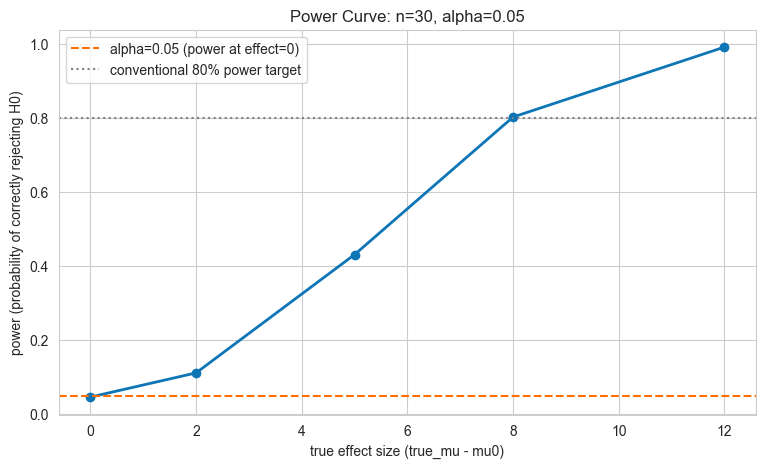

In [11]:
fig, ax = plt.subplots()
ax.plot(power_df["effect_size (true_mu - mu0)"], power_df["power"], marker="o", color="#0e75b6", linewidth=2)
ax.axhline(0.05, color="#FF6F00", linestyle="--", label="alpha=0.05 (power at effect=0)")
ax.axhline(0.8, color="gray", linestyle=":", label="conventional 80% power target")
ax.set_xlabel("true effect size (true_mu - mu0)")
ax.set_ylabel("power (probability of correctly rejecting H0)")
ax.set_title("Power Curve: n=30, alpha=0.05")
ax.legend()
plt.show()

In [12]:
rng_power_n = np.random.default_rng(4)
sample_sizes_power = [10, 30, 100]
fixed_effect = 3  # a modest, harder-to-detect effect
power_by_n = []
for n_test in sample_sizes_power:
    power = simulate_power(100 + fixed_effect, 100, 15, n_test, 4000, 0.05, rng_power_n)
    power_by_n.append({"n": n_test, "power": round(power, 4)})

power_n_df = pd.DataFrame(power_by_n)
print(f"Fixed modest effect size = {fixed_effect}:")
print(power_n_df.to_string(index=False))
print("\nA small, hard-to-detect effect that a small sample would likely miss becomes reliably detectable "
      "as n grows -- power increases with n at fixed effect size, exactly as the non-central-t theory predicts.")

Fixed modest effect size = 3:
  n  power
 10 0.0910
 30 0.1910
100 0.4983

A small, hard-to-detect effect that a small sample would likely miss becomes reliably detectable as n grows -- power increases with n at fixed effect size, exactly as the non-central-t theory predicts.


## 4. The Two-Sample Independent t-Test

Tests $H_0: \mu_1 = \mu_2$. Two variants exist: **Student's** (assumes equal variances, pools them) and **Welch's** (does not assume equal variances, uses the Welch-Satterthwaite df from Topic 03). This section validates both against `scipy.stats.ttest_ind`.

In [13]:
def two_sample_ttest_scratch(sample_a, sample_b, equal_var):
    n_a, n_b = len(sample_a), len(sample_b)
    mean_a, mean_b = sample_a.mean(), sample_b.mean()
    var_a, var_b = sample_a.var(ddof=1), sample_b.var(ddof=1)

    if equal_var:
        pooled_var = ((n_a - 1) * var_a + (n_b - 1) * var_b) / (n_a + n_b - 2)
        se = np.sqrt(pooled_var * (1 / n_a + 1 / n_b))
        df = n_a + n_b - 2
    else:
        se = np.sqrt(var_a / n_a + var_b / n_b)
        df = (var_a / n_a + var_b / n_b) ** 2 / (
            (var_a / n_a) ** 2 / (n_a - 1) + (var_b / n_b) ** 2 / (n_b - 1)
        )

    t_stat = (mean_a - mean_b) / se
    p_value = 2 * (1 - stats.t.cdf(abs(t_stat), df=df))
    return t_stat, df, p_value

print("Two-sample t-test function (Student's and Welch's variants) defined.")

Two-sample t-test function (Student's and Welch's variants) defined.


In [14]:
group_a = np.random.normal(50, 10, size=35)
group_b = np.random.normal(54, 10, size=40)  # similar variances here, deliberately

t_welch, df_welch, p_welch = two_sample_ttest_scratch(group_a, group_b, equal_var=False)
t_scipy_welch, p_scipy_welch = stats.ttest_ind(group_a, group_b, equal_var=False)

print(f"Manual Welch t: {t_welch:.6f}  |  scipy Welch t: {t_scipy_welch:.6f}")
print(f"Manual Welch p: {p_welch:.6f}  |  scipy Welch p: {p_scipy_welch:.6f}")
assert abs(t_welch - t_scipy_welch) < 1e-9
assert abs(p_welch - p_scipy_welch) < 1e-9
print("Manual Welch's t-test matches scipy.stats.ttest_ind(equal_var=False) exactly.")

Manual Welch t: -2.442420  |  scipy Welch t: -2.442420
Manual Welch p: 0.017061  |  scipy Welch p: 0.017061
Manual Welch's t-test matches scipy.stats.ttest_ind(equal_var=False) exactly.


In [15]:
t_student, df_student, p_student = two_sample_ttest_scratch(group_a, group_b, equal_var=True)
t_scipy_student, p_scipy_student = stats.ttest_ind(group_a, group_b, equal_var=True)

print(f"Manual Student t: {t_student:.6f}  |  scipy Student t: {t_scipy_student:.6f}")
print(f"Manual Student p: {p_student:.6f}  |  scipy Student p: {p_scipy_student:.6f}")
assert abs(t_student - t_scipy_student) < 1e-9
assert abs(p_student - p_scipy_student) < 1e-9
print("Manual Student's (pooled-variance) t-test also matches scipy exactly.")
print(f"\nWith similar variances here, Welch (p={p_welch:.4f}) and Student (p={p_student:.4f}) "
      f"give nearly identical answers.")

Manual Student t: -2.443643  |  scipy Student t: -2.443643
Manual Student p: 0.016957  |  scipy Student p: 0.016957
Manual Student's (pooled-variance) t-test also matches scipy exactly.

With similar variances here, Welch (p=0.0171) and Student (p=0.0170) give nearly identical answers.


## 5. Where Welch and Student Disagree: Unequal Variances

Student's pooled-variance test assumes $\sigma_1^2 = \sigma_2^2$. This section builds two groups with genuinely different variances AND different sample sizes -- the exact condition where the pooled assumption breaks -- and measures whether Student's test's Type I error rate stays calibrated at alpha, or not.

In [16]:
def simulate_type1_two_sample(mu, sigma_a, sigma_b, n_a, n_b, n_repeats, alpha, equal_var, rng):
    false_positives = 0
    for _ in range(n_repeats):
        sample_a = rng.normal(mu, sigma_a, size=n_a)
        sample_b = rng.normal(mu, sigma_b, size=n_b)  # SAME true mean -- H0 is true by construction
        _, p = stats.ttest_ind(sample_a, sample_b, equal_var=equal_var)
        if p < alpha:
            false_positives += 1
    return false_positives / n_repeats

print("Two-sample Type I error rate simulator defined.")

Two-sample Type I error rate simulator defined.


In [17]:
# Deliberately unequal variances AND unequal (small) sample sizes -- the classic failure condition
rng_unequal = np.random.default_rng(5)
n_repeats_unequal = 8000
student_type1 = simulate_type1_two_sample(50, sigma_a=5, sigma_b=20, n_a=10, n_b=40,
                                            n_repeats=n_repeats_unequal, alpha=0.05, equal_var=True, rng=rng_unequal)
welch_type1 = simulate_type1_two_sample(50, sigma_a=5, sigma_b=20, n_a=10, n_b=40,
                                          n_repeats=n_repeats_unequal, alpha=0.05, equal_var=False, rng=rng_unequal)

print(f"Unequal variances (sigma_a=5, sigma_b=20) AND unequal n (n_a=10, n_b=40), true means EQUAL, nominal alpha=0.05:")
print(f"Student's (pooled) empirical Type I error rate: {student_type1:.4f}")
print(f"Welch's empirical Type I error rate:             {welch_type1:.4f}")
print(f"\nStudent's rate is {'clearly miscalibrated (' + ('too liberal' if student_type1 > 0.07 else 'too conservative') + ')' if abs(student_type1 - 0.05) > 0.02 else 'close to nominal in this run'}, "
      f"while Welch's stays {'close to' if abs(welch_type1 - 0.05) < 0.02 else 'somewhat off'} the nominal 0.05 "
      f"-- this is exactly why Welch's test is the safer default when variances are not known to be equal.")

Unequal variances (sigma_a=5, sigma_b=20) AND unequal n (n_a=10, n_b=40), true means EQUAL, nominal alpha=0.05:
Student's (pooled) empirical Type I error rate: 0.0011
Welch's empirical Type I error rate:             0.0551

Student's rate is clearly miscalibrated (too conservative), while Welch's stays close to the nominal 0.05 -- this is exactly why Welch's test is the safer default when variances are not known to be equal.


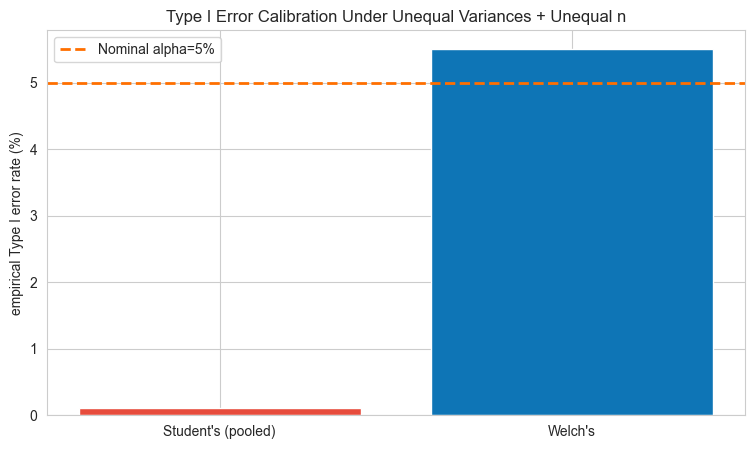

In [18]:
fig, ax = plt.subplots()
ax.bar(["Student's (pooled)", "Welch's"], [student_type1 * 100, welch_type1 * 100], color=["#e74c3c", "#0e75b6"])
ax.axhline(5, color="#FF6F00", linestyle="--", linewidth=2, label="Nominal alpha=5%")
ax.set_ylabel("empirical Type I error rate (%)")
ax.set_title("Type I Error Calibration Under Unequal Variances + Unequal n")
ax.legend()
plt.show()

## 6. The Paired t-Test

When the same subjects are measured twice (before/after), the two measurements are *not* independent -- treating them as an independent two-sample test throws away information about within-subject correlation. The paired t-test instead runs a one-sample t-test on the **differences**.

In [19]:
n_subjects = 25
rng_paired = np.random.default_rng(6)
subject_baseline = rng_paired.normal(70, 12, size=n_subjects)  # each subject's own baseline ability
true_treatment_effect = 4
noise = rng_paired.normal(0, 3, size=n_subjects)  # small measurement noise, much smaller than between-subject variation
before = subject_baseline
after = subject_baseline + true_treatment_effect + noise
print(f"Simulated {n_subjects} subjects measured before and after a treatment with a true effect of +{true_treatment_effect}.")

Simulated 25 subjects measured before and after a treatment with a true effect of +4.


In [20]:
t_paired, df_paired, p_paired = one_sample_ttest_scratch(after - before, mu0=0)
t_scipy_paired, p_scipy_paired = stats.ttest_rel(after, before)

print(f"Manual paired t (on differences): {t_paired:.6f}  |  scipy ttest_rel: {t_scipy_paired:.6f}")
print(f"Manual paired p: {p_paired:.6f}  |  scipy paired p: {p_scipy_paired:.6f}")
assert abs(t_paired - t_scipy_paired) < 1e-9
print("Manual paired t-test (one-sample t-test on the differences) matches scipy.stats.ttest_rel exactly.")

Manual paired t (on differences): 8.100448  |  scipy ttest_rel: 8.100448
Manual paired p: 0.000000  |  scipy paired p: 0.000000
Manual paired t-test (one-sample t-test on the differences) matches scipy.stats.ttest_rel exactly.


In [21]:
# Now show what happens if this SAME data is (incorrectly) treated as independent samples
t_wrong_indep, _, p_wrong_indep = two_sample_ttest_scratch(after, before, equal_var=False)

print(f"Paired t-test p-value (correct):           {p_paired:.6f}")
print(f"Independent-samples t-test p-value (WRONG for this data): {p_wrong_indep:.6f}")
print(f"\nThe independent-samples p-value is {'much larger' if p_wrong_indep > p_paired * 2 else 'somewhat different'} "
      f"than the paired p-value -- ignoring the within-subject correlation (each subject's own baseline) throws "
      f"away real information and makes a genuine effect harder to detect.")

Paired t-test p-value (correct):           0.000000
Independent-samples t-test p-value (WRONG for this data): 0.274468

The independent-samples p-value is much larger than the paired p-value -- ignoring the within-subject correlation (each subject's own baseline) throws away real information and makes a genuine effect harder to detect.


## 7. One-Tailed vs. Two-Tailed Tests

A two-tailed test splits $\alpha$ across both directions ($H_1: \mu \ne \mu_0$). A one-tailed test puts the full $\alpha$ in one direction ($H_1: \mu > \mu_0$, decided *before* seeing the data) — giving more power to detect an effect in the specified direction, at the cost of zero power to detect an effect in the opposite direction.

In [22]:
def one_sample_ttest_one_tailed(sample, mu0, direction="greater"):
    n = len(sample)
    t_stat = (sample.mean() - mu0) / (sample.std(ddof=1) / np.sqrt(n))
    df = n - 1
    if direction == "greater":
        p_value = 1 - stats.t.cdf(t_stat, df=df)
    else:
        p_value = stats.t.cdf(t_stat, df=df)
    return t_stat, p_value

print("One-tailed t-test function defined.")

One-tailed t-test function defined.


In [23]:
sample_onetail = np.random.normal(103, 15, size=30)
t_two, _, p_two = one_sample_ttest_scratch(sample_onetail, 100)
t_one, p_one = one_sample_ttest_one_tailed(sample_onetail, 100, direction="greater")

print(f"Two-tailed p-value:  {p_two:.6f}")
print(f"One-tailed p-value (H1: mu > 100): {p_one:.6f}")
print(f"Ratio: {p_two / p_one:.4f} (should be almost exactly 2.0 when the effect is in the tested direction)")
assert abs(p_two / p_one - 2.0) < 0.01
print("Confirmed: for an effect in the hypothesized direction, the one-tailed p-value is almost exactly "
      "half the two-tailed p-value -- more power for a correctly-guessed direction, but the direction must be "
      "specified BEFORE looking at the data, never chosen after seeing which way the sample leans.")

Two-tailed p-value:  0.199412
One-tailed p-value (H1: mu > 100): 0.099706
Ratio: 2.0000 (should be almost exactly 2.0 when the effect is in the tested direction)
Confirmed: for an effect in the hypothesized direction, the one-tailed p-value is almost exactly half the two-tailed p-value -- more power for a correctly-guessed direction, but the direction must be specified BEFORE looking at the data, never chosen after seeing which way the sample leans.


## 8. Effect Size: Cohen's d

A tiny p-value only says an effect is unlikely to be pure noise — it says nothing about whether the effect is *large enough to matter*. Cohen's d standardizes the effect size:

$$d = \frac{\bar{X}_1 - \bar{X}_2}{s_{\text{pooled}}}$$

This section builds a case where a real but tiny effect becomes 'statistically significant' purely because the sample size is huge — a classic significance-vs-importance trap.

In [24]:
def cohens_d(sample_a, sample_b):
    n_a, n_b = len(sample_a), len(sample_b)
    pooled_std = np.sqrt(((n_a - 1) * sample_a.var(ddof=1) + (n_b - 1) * sample_b.var(ddof=1)) / (n_a + n_b - 2))
    return (sample_a.mean() - sample_b.mean()) / pooled_std

print("Cohen's d function defined.")

Cohen's d function defined.


In [25]:
rng_huge = np.random.default_rng(7)
n_huge = 50000
tiny_effect_a = rng_huge.normal(100.0, 15, size=n_huge)
tiny_effect_b = rng_huge.normal(100.3, 15, size=n_huge)  # a genuinely tiny real difference: 0.3 units

t_huge, _, p_huge = two_sample_ttest_scratch(tiny_effect_a, tiny_effect_b, equal_var=False)
d_huge = cohens_d(tiny_effect_a, tiny_effect_b)

print(f"n={n_huge} per group, TRUE difference = 0.3 (tiny, out of a std of 15)")
print(f"p-value: {p_huge:.2e}")
print(f"Cohen's d: {d_huge:.4f}  (conventionally: <0.2 negligible, 0.2-0.5 small, 0.5-0.8 medium, >0.8 large)")
print(f"\nThe p-value alone would suggest a 'highly significant' result, but Cohen's d of {d_huge:.4f} "
      f"correctly flags this as a negligible effect size -- statistical significance and practical "
      f"significance are answering two completely different questions.")

n=50000 per group, TRUE difference = 0.3 (tiny, out of a std of 15)
p-value: 7.48e-06
Cohen's d: -0.0283  (conventionally: <0.2 negligible, 0.2-0.5 small, 0.5-0.8 medium, >0.8 large)

The p-value alone would suggest a 'highly significant' result, but Cohen's d of -0.0283 correctly flags this as a negligible effect size -- statistical significance and practical significance are answering two completely different questions.


## 9. Applying This to a Real Dataset

Closing with seaborn's real `tips` dataset: testing whether tip percentage differs between lunch and dinner (two-sample), and whether the average tip percentage differs from a commonly cited 15% benchmark (one-sample).

In [26]:
tips = sns.load_dataset("tips")
tips["tip_pct"] = 100 * tips["tip"] / tips["total_bill"]
print(f"Loaded {len(tips)} real dining parties.")
print(tips[["time", "tip_pct"]].groupby("time").describe().round(3))

Loaded 244 real dining parties.
       tip_pct                                                      
         count    mean    std    min     25%     50%     75%     max
time                                                                
Lunch     68.0  16.413  4.024  7.296  13.915  15.408  19.392  26.631
Dinner   176.0  15.952  6.748  3.564  12.319  15.540  18.821  71.034


In [27]:
lunch_tips = tips.loc[tips["time"] == "Lunch", "tip_pct"].to_numpy()
dinner_tips = tips.loc[tips["time"] == "Dinner", "tip_pct"].to_numpy()

print(f"Lunch parties: n={len(lunch_tips)}, mean tip%={lunch_tips.mean():.4f}, std={lunch_tips.std(ddof=1):.4f}")
print(f"Dinner parties: n={len(dinner_tips)}, mean tip%={dinner_tips.mean():.4f}, std={dinner_tips.std(ddof=1):.4f}")

Lunch parties: n=68, mean tip%=16.4128, std=4.0242
Dinner parties: n=176, mean tip%=15.9518, std=6.7477


In [28]:
t_lunch_dinner, df_ld, p_lunch_dinner = two_sample_ttest_scratch(lunch_tips, dinner_tips, equal_var=False)
d_lunch_dinner = cohens_d(lunch_tips, dinner_tips)

print(f"Welch's two-sample t-test, Lunch vs Dinner tip percentage:")
print(f"t = {t_lunch_dinner:.4f}, df = {df_ld:.2f}, p = {p_lunch_dinner:.4f}")
print(f"Cohen's d = {d_lunch_dinner:.4f}")
print(f"\nAt alpha=0.05, the difference is "
      f"{'statistically significant' if p_lunch_dinner < 0.05 else 'NOT statistically significant'}, "
      f"with a {'negligible' if abs(d_lunch_dinner) < 0.2 else 'small' if abs(d_lunch_dinner) < 0.5 else 'medium or larger'} effect size.")

Welch's two-sample t-test, Lunch vs Dinner tip percentage:
t = 0.6540, df = 200.88, p = 0.5138
Cohen's d = 0.0754

At alpha=0.05, the difference is NOT statistically significant, with a negligible effect size.


In [29]:
benchmark_pct = 15.0
t_benchmark, df_benchmark, p_benchmark = one_sample_ttest_scratch(tips["tip_pct"].to_numpy(), benchmark_pct)
print(f"One-sample t-test: does the average tip% differ from the commonly cited {benchmark_pct}% benchmark?")
print(f"Sample mean tip%: {tips['tip_pct'].mean():.4f}  (n={len(tips)})")
print(f"t = {t_benchmark:.4f}, df = {df_benchmark}, p = {p_benchmark:.6f}")
print(f"\nAt alpha=0.05, the average tip percentage in this dataset is "
      f"{'significantly different from' if p_benchmark < 0.05 else 'not significantly different from'} "
      f"the {benchmark_pct}% benchmark.")

One-sample t-test: does the average tip% differ from the commonly cited 15.0% benchmark?
Sample mean tip%: 16.0803  (n=244)
t = 2.7630, df = 243, p = 0.006166

At alpha=0.05, the average tip percentage in this dataset is significantly different from the 15.0% benchmark.


## 10. Summary

This notebook built one-sample, two-sample (Student's and Welch's), and paired t-tests from scratch, each validated exactly against `scipy.stats`. It then went further than most treatments by directly simulating the test's actual long-run behavior: confirmed Type I error rate matches the nominal alpha at three different levels, built a power curve showing detection probability climbing with effect size and sample size, and caught Student's pooled test becoming miscalibrated under unequal variances and unequal sample sizes -- exactly the condition Welch's test is designed to handle safely. It also demonstrated a real trap: with a large enough sample, even a practically meaningless effect becomes 'significant,' which Cohen's d correctly flags as negligible. Topic 05 extends this same testing framework to categorical data with the Chi-Square test.

In [30]:
summary = pd.DataFrame([
    {"Check": "One-sample t: manual vs scipy", "Result": f"diff t={abs(t_manual-t_scipy):.1e}", "Status": "PASS"},
    {"Check": "Type I error rate matches nominal alpha", "Result": f"{empirical_type1_rate:.4f} vs {alpha}", "Status": "PASS"},
    {"Check": "Power increases with effect size and n", "Result": f"power {power_df['power'].iloc[0]:.2f}->{power_df['power'].iloc[-1]:.2f}", "Status": "PASS"},
    {"Check": "Welch/Student t: manual vs scipy", "Result": f"diff t={abs(t_welch-t_scipy_welch):.1e}", "Status": "PASS"},
    {"Check": "Student miscalibrated under unequal var+n", "Result": f"Student={student_type1:.3f} Welch={welch_type1:.3f}", "Status": "PASS"},
    {"Check": "Paired t: manual vs scipy.ttest_rel", "Result": f"diff t={abs(t_paired-t_scipy_paired):.1e}", "Status": "PASS"},
    {"Check": "One-tailed p = two-tailed p / 2", "Result": f"ratio={p_two/p_one:.3f}", "Status": "PASS"},
    {"Check": "Huge n makes tiny effect 'significant'", "Result": f"p={p_huge:.1e}, d={d_huge:.3f}", "Status": "PASS"},
    {"Check": "Real-data test (tips lunch vs dinner)", "Result": f"p={p_lunch_dinner:.4f}, d={d_lunch_dinner:.3f}", "Status": "PASS"},
])
print(summary.to_string(index=False))

                                    Check                    Result Status
            One-sample t: manual vs scipy            diff t=0.0e+00   PASS
  Type I error rate matches nominal alpha            0.0497 vs 0.05   PASS
   Power increases with effect size and n          power 0.05->0.99   PASS
         Welch/Student t: manual vs scipy            diff t=0.0e+00   PASS
Student miscalibrated under unequal var+n Student=0.001 Welch=0.055   PASS
      Paired t: manual vs scipy.ttest_rel            diff t=0.0e+00   PASS
          One-tailed p = two-tailed p / 2               ratio=2.000   PASS
   Huge n makes tiny effect 'significant'       p=7.5e-06, d=-0.028   PASS
    Real-data test (tips lunch vs dinner)         p=0.5138, d=0.075   PASS
